# Day 10 — 股票数据获取实战
## 今日目标：从网上拉真数据 → 算涨跌幅 → 做统计对比

两个数据源：
- **yfinance**：美股（Yahoo Finance）— 今天被限流，了解API即可
- **akshare**：A股（东方财富等）— 今天主力，真实数据！

In [1]:
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("环境就绪 ✅")

环境就绪 ✅


## 1. 拉一只股票：茅台 600519 近一年数据

In [2]:
# ak.stock_zh_a_hist() — A股日线数据
df = ak.stock_zh_a_hist(symbol='600519', period='daily', start_date='20250701', end_date='20260712', adjust='qfq')

print('shape:', df.shape)
df.head()

shape: (250, 12)


,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2025-07-01,600519,1357.02,1353.12,1359.96,1351.33,19878,2.794423e+09,0.64,-0.33,-4.42,0.16
1,2025-07-02,600519,1357.52,1357.62,1362.82,1348.02,26218,3.689246e+09,1.09,0.33,4.50,0.21
2,2025-07-03,600519,1360.02,1363.62,1370.71,1356.02,24413,3.456733e+09,1.08,0.44,6.00,0.19
3,2025-07-04,600519,1363.72,1370.24,1379.91,1358.03,28767,4.086547e+09,1.60,0.49,6.62,0.23
4,2025-07-07,600519,1370.30,1358.72,1371.52,1358.03,23855,3.370563e+09,0.98,-0.84,-11.52,0.19


In [3]:
# 列太多了，只保留核心列，改名
df = df[['日期', '开盘', '收盘', '最高', '最低', '成交量', '涨跌幅']].copy()
df['日期'] = pd.to_datetime(df['日期'])
df.set_index('日期', inplace=True)
df.columns = ['开盘', '收盘', '最高', '最低', '成交量', '涨跌幅']
df.head()

,开盘,收盘,最高,最低,成交量,涨跌幅
日期,,,,,,
2025-07-01,1357.02,1353.12,1359.96,1351.33,19878,-0.33
2025-07-02,1357.52,1357.62,1362.82,1348.02,26218,0.33
2025-07-03,1360.02,1363.62,1370.71,1356.02,24413,0.44
2025-07-04,1363.72,1370.24,1379.91,1358.03,28767,0.49
2025-07-07,1370.30,1358.72,1371.52,1358.03,23855,-0.84


## 2. 五大核心操作复习（用真数据）

In [4]:
# ① shape — 多少天数据？
df.shape

(250, 6)

In [5]:
# ② 取列 — 收盘价
df['收盘'].head()

日期
2025-07-01    1353.12
2025-07-02    1357.62
2025-07-03    1363.62
2025-07-04    1370.24
2025-07-07    1358.72
Name: 收盘, dtype: float64

In [6]:
# ③ describe() — 价格统计
df.describe()

,开盘,收盘,最高,最低,成交量,涨跌幅
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,1369.302920,1368.699040,1380.893040,1358.937960,40324.228000,-0.039440
std,70.008155,69.901381,69.577081,69.885454,18269.677712,1.311545
min,1169.000000,1168.630000,1191.990000,1151.010000,17803.000000,-3.880000
25%,1359.052500,1358.795000,1368.270000,1351.980000,28111.000000,-0.787500
50%,1382.035000,1381.730000,1391.780000,1372.985000,36406.500000,-0.155000
75%,1410.080000,1411.557500,1423.040000,1399.802500,47479.250000,0.440000
max,1526.980000,1526.980000,1539.980000,1486.980000,189534.000000,8.800000


In [7]:
# ④ 筛选 — 涨幅超过3%的日子
df[df['涨跌幅'] > 3].head()

,开盘,收盘,最高,最低,成交量,涨跌幅
日期,,,,,,
2026-01-05,1356.98,1397.98,1403.86,1356.98,70949,3.62
2026-01-29,1306.98,1409.70,1416.98,1301.04,189534,8.80
2026-02-03,1416.98,1446.90,1448.79,1415.01,86321,3.43
2026-02-04,1456.98,1496.98,1505.25,1445.98,109123,3.46
2026-03-16,1391.98,1432.16,1437.98,1391.98,60086,3.36


In [8]:
# ⑤ 排序 — 成交量最大的10天
df.sort_values('成交量', ascending=False).head(10)

,开盘,收盘,最高,最低,成交量,涨跌幅
日期,,,,,,
2026-01-29,1306.98,1409.70,1416.98,1301.04,189534,8.80
2026-02-04,1456.98,1496.98,1505.25,1445.98,109123,3.46
2026-04-17,1371.98,1379.22,1392.98,1371.85,96825,-3.88
2026-01-30,1406.98,1372.98,1406.98,1372.98,94480,-2.60
2026-02-05,1491.98,1526.98,1536.98,1486.98,91623,2.00
2026-02-03,1416.98,1446.90,1448.79,1415.01,86321,3.43
2026-02-02,1396.98,1398.98,1430.56,1383.60,85724,1.89
2026-05-27,1240.00,1274.98,1290.98,1222.08,82728,2.38
2026-01-26,1312.49,1313.98,1326.98,1297.10,80166,0.38


## 3. 🆕 核心计算（Day10 新内容）

In [9]:
# ① 日收益率（今天相对昨天的涨跌%）
# pct_change() = (今天-昨天)/昨天
df['日收益率'] = df['收盘'].pct_change()
df[['收盘', '日收益率']].head(10)

,收盘,日收益率
日期,,
2025-07-01,1353.12,NaN
2025-07-02,1357.62,0.003326
2025-07-03,1363.62,0.004419
2025-07-04,1370.24,0.004855
2025-07-07,1358.72,-0.008407
2025-07-08,1364.13,0.003982
2025-07-09,1366.90,0.002031
2025-07-10,1374.52,0.005575
2025-07-11,1375.02,0.000364


In [10]:
# ② 累计收益率（1元变多少？）
df['累计收益率'] = (1 + df['日收益率']).cumprod() - 1
df[['收盘', '日收益率', '累计收益率']].tail()

,收盘,日收益率,累计收益率
日期,,,
2026-07-06,1206.91,0.010432,-0.108054
2026-07-07,1188.80,-0.015005,-0.121438
2026-07-08,1199.30,0.008832,-0.113678
2026-07-09,1182.19,-0.014267,-0.126323
2026-07-10,1204.98,0.019278,-0.109480


In [11]:
# ③ 移动平均线 MA5（近5天收盘价平均值）
df['MA5'] = df['收盘'].rolling(window=5).mean()
df['MA20'] = df['收盘'].rolling(window=20).mean()
df[['收盘', 'MA5', 'MA20']].tail(10)

,收盘,MA5,MA20
日期,,,
2026-06-29,1194.96,1184.352,1226.5000
2026-06-30,1185.49,1182.564,1221.6955
2026-07-01,1193.01,1185.234,1217.3860
2026-07-02,1203.00,1189.018,1214.8415
2026-07-03,1194.45,1194.182,1212.5650
2026-07-06,1206.91,1196.572,1210.6685
2026-07-07,1188.80,1197.234,1208.3605
2026-07-08,1199.30,1198.492,1206.9265
2026-07-09,1182.19,1194.330,1203.6430


In [12]:
# ④ 年化指标
日均收益率 = df['日收益率'].mean()
日波动率 = df['日收益率'].std()
年化收益率 = 日均收益率 * 252  # 一年约252个交易日
年化波动率 = 日波动率 * (252 ** 0.5)
夏普比率 = 年化收益率 / 年化波动率  if 年化波动率 != 0 else 0

print(f'茅台近一年：')
print(f'  日均收益率: {日均收益率:.4%}')
print(f'  年化收益率: {年化收益率:.2%}')
print(f'  年化波动率: {年化波动率:.2%}')
print(f'  夏普比率:   {夏普比率:.2f}')

茅台近一年：
  日均收益率: -0.0381%
  年化收益率: -9.59%
  年化波动率: 20.86%
  夏普比率:   -0.46


## 4. 🔥 多只股票对比（下午任务）

In [13]:
# 拉5只不同行业的龙头
stocks = {
    '茅台': '600519',   # 白酒
    '比亚迪': '002594', # 新能源车
    '恒瑞医药': '600276', # 医药
    '海康威视': '002415', # 安防/AI
    '招商银行': '600036', # 银行
}

all_data = {}
for name, code in stocks.items():
    df_stock = ak.stock_zh_a_hist(symbol=code, period='daily', start_date='20250701', end_date='20260712', adjust='qfq')
    df_stock = df_stock[['日期', '收盘']].copy()
    df_stock['日期'] = pd.to_datetime(df_stock['日期'])
    df_stock.set_index('日期', inplace=True)
    df_stock.columns = [name]
    all_data[name] = df_stock[name]
    print(f'{name} ✅ {len(df_stock)}天')

# 合并成一张大表
df_all = pd.DataFrame(all_data)
print(f'\n合并后 shape: {df_all.shape}')
df_all.head()

茅台 ✅ 250天
比亚迪 ✅ 250天
恒瑞医药 ✅ 250天
海康威视 ✅ 250天
招商银行 ✅ 250天

合并后 shape: (250, 5)


,茅台,比亚迪,恒瑞医药,海康威视,招商银行
日期,,,,,
2025-07-01,1353.12,109.12,52.26,26.38,42.43
2025-07-02,1357.62,108.90,52.05,26.36,42.88
2025-07-03,1363.62,110.20,52.27,26.56,42.59
2025-07-04,1370.24,109.01,53.06,26.46,43.05
2025-07-07,1358.72,108.21,52.45,26.28,43.18


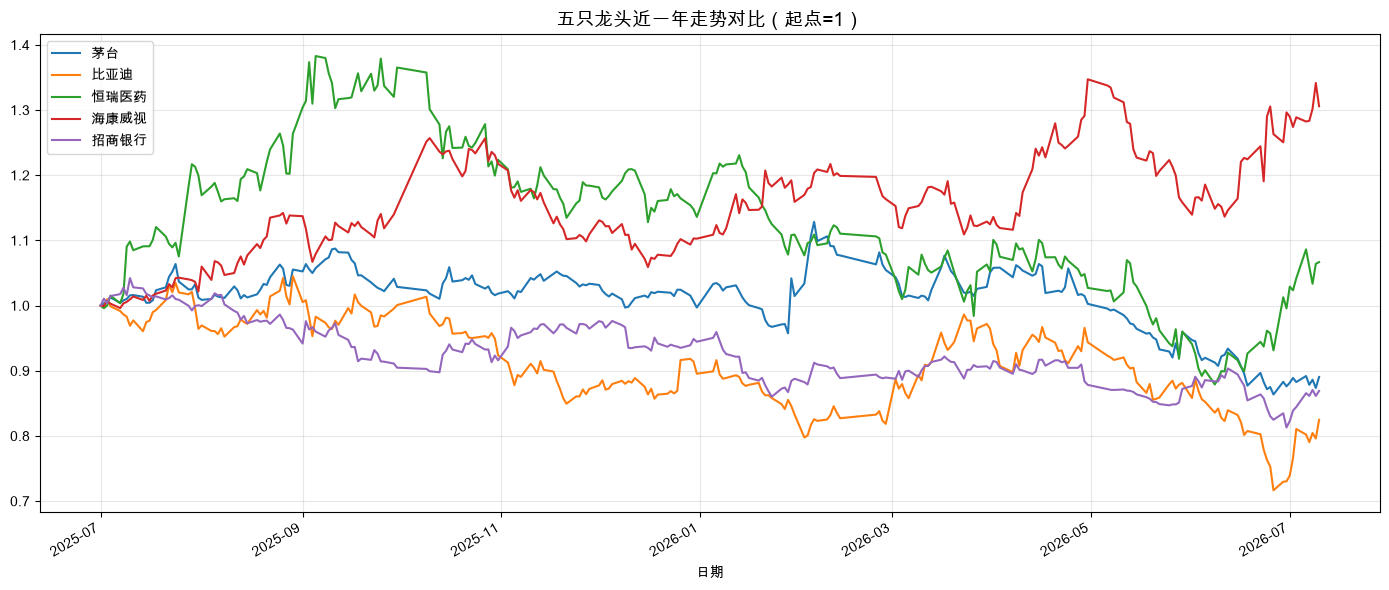

In [14]:
# 归一化：都从1开始，只看相对走势
df_norm = df_all / df_all.iloc[0]
df_norm.plot(figsize=(14, 6), linewidth=1.5)
plt.title('五只龙头近一年走势对比（起点=1）', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/Day10_五股对比.png', dpi=150)
plt.show()

In [15]:
# 涨跌幅对比表
returns = df_all.iloc[-1] / df_all.iloc[0] - 1  # 期末/期初 -1
returns = returns.sort_values(ascending=False)
print('近一年涨跌幅排名：')
for name, r in returns.items():
    bar = '🟢' if r > 0 else '🔴'
    print(f'  {bar} {name}: {r:+.2%}')

近一年涨跌幅排名：
  🟢 海康威视: +30.59%
  🟢 恒瑞医药: +6.68%
  🔴 茅台: -10.95%
  🔴 招商银行: -13.08%
  🔴 比亚迪: -17.52%


In [16]:
# 谁最稳？谁最猛？
daily_returns = df_all.pct_change()
stats = pd.DataFrame({
    '年化收益': daily_returns.mean() * 252,
    '年化波动': daily_returns.std() * (252 ** 0.5),
    '夏普比率': (daily_returns.mean() / daily_returns.std()) * (252 ** 0.5)
})
stats.style.format('{:.2%}').background_gradient(cmap='RdYlGn')

,年化收益,年化波动,夏普比率
茅台,-9.59%,20.86%,-45.98%
比亚迪,-15.51%,28.38%,-54.67%
恒瑞医药,12.47%,34.72%,35.90%
海康威视,30.61%,26.98%,113.43%
招商银行,-12.79%,16.76%,-76.27%


## 5. yfinance API（了解，今天限流不可用）

```python
import yfinance as yf

# 同样的逻辑，换个函数名：
aapl = yf.Ticker('AAPL')
df = aapl.history(period='1y')  # 等价于 ak.stock_zh_a_hist()
aapl.info  # 公司信息（akshare没有这个）

# 批量下载
df = yf.download(['AAPL', 'TSLA', 'MSFT'], period='1y')
```

核心API对照：
| 功能 | yfinance | akshare |
|------|----------|--------|
| A股数据 | ❌ | `stock_zh_a_hist()` |
| 美股数据 | `Ticker().history()` | ❌ |
| 公司信息 | `.info` | ❌ |

**记住：换数据源就是换函数名，后面分析逻辑一模一样。**